# Původní SAPCE a inverzní analýza Oakwood




## Nastavení a importy

In [3]:
import json
import pickle
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import openturns as ot
from scipy.integrate import trapezoid
from scipy.linalg import solve_triangular
from scipy.stats import norm, uniform

SEED = 1
N_TRAIN = 100
N_CALIB = 100
N_TEST = 200
N_SOBOL = 256
N_GRID = 301
MAX_COND = 1e2
CR = 1e-8
TIMEOUT = 600

folder = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
WORKER_PATH = folder / "sapce_worker.py"
if not WORKER_PATH.is_file():
    raise FileNotFoundError("Doplň sem svůj sapce_worker.py, sapce.py a jejich pomocné moduly.")
ot.Log.Show(ot.Log.NONE)
ot.RandomGenerator.SetSeed(SEED)
rng = np.random.default_rng(SEED)

## Data a oddělené množiny

In [5]:
data = pd.read_excel(folder / "Oakwood.xlsx", header=None).to_numpy(dtype=float)
if data.ndim != 2 or data.shape[1] <= 12 or not np.isfinite(data).all():
    raise ValueError("Očekávám 12 vstupů a číselné výstupy bez NaN/Inf.")
X = data[:, :12]
channels = np.unique(np.linspace(0, data.shape[1] - 13, 5, dtype=int))
Y_all = data[:, 12:]
Y = Y_all[:, channels]
names = ["Ec", "Rel", "Erat_1", "E50_1", "c_1", "phi_1", "k0_1",
         "Erat_2", "E50_2", "c_2", "phi_2", "k0_2"]
if len(X) < 1 + N_TRAIN + N_CALIB + N_TEST:
    raise ValueError("Málo řádků pro zadané rozdělení dat.")
ids = rng.permutation(len(X))
obs = int(ids[0])
train = ids[1:1 + N_TRAIN]
calib = ids[1 + N_TRAIN:1 + N_TRAIN + N_CALIB]
test = ids[1 + N_TRAIN + N_CALIB:1 + N_TRAIN + N_CALIB + N_TEST]

# Stejný způsob normalizace jako v beam_dummy; její parametry určí jen trénink.
X_mu, X_sig = X[train].mean(axis=0), X[train].std(axis=0)
Y_mu_all, Y_sig_all = Y_all[train].mean(axis=0), Y_all[train].std(axis=0)
Y_mu, Y_sig = Y_mu_all[channels], Y_sig_all[channels]
if np.any(X_sig <= 0) or np.any(Y_sig <= 0):
    raise ValueError("Nulový rozptyl vstupu nebo výstupu v tréninku.")
Z_tr = (X[train] - X_mu) / X_sig
Y_sig_all = np.where(Y_sig_all > 0, Y_sig_all, 1.0)
Y_tr = (Y_all[train] - Y_mu_all) / Y_sig_all
dist_joint = ot.ComposedDistribution([ot.Normal(0.0, 1.0)] * 12)

## Stejný worker a datové rozhraní jako v beam_dummy.ipynb

In [7]:
def run_sapce(Z_tr, Y_tr, Z_test):
    with tempfile.TemporaryDirectory() as tmp:
        in_f, out_f = Path(tmp) / "in.pkl", Path(tmp) / "out.pkl"
        with in_f.open("wb") as f:
            pickle.dump({"dist_joint": dist_joint, "Z_tr": Z_tr,
                         "Y_tr": Y_tr, "Z_test": Z_test}, f)
        args = json.dumps({"in_file": str(in_f), "out_file": str(out_f),
                           "max_cond": MAX_COND, "cr": CR})
        result = subprocess.run(
            [sys.executable, str(WORKER_PATH), args], cwd=folder, timeout=TIMEOUT,
            stdout=subprocess.PIPE, stderr=subprocess.PIPE,
        )
        if result.returncode != 0 or not out_f.is_file():
            raise RuntimeError("SAPCE worker selhal:\n" + result.stderr.decode(errors="replace")[-2500:])
        with out_f.open("rb") as f:
            pred = np.asarray(pickle.load(f), dtype=float)
    if pred.shape != (len(Z_test), Y_tr.shape[1]) or not np.isfinite(pred).all():
        raise ValueError("Worker vrátil jiný tvar predikce nebo NaN/Inf.")
    return pred

## Body pro citlivost a inverzi; model se natrénuje pouze jednou

In [9]:
# Fyzikální priory z původního notebooku. Standardizace sama nevytváří normalitu.
priors = [norm(13, 1), uniform(30, 40), uniform(2, 1), norm(65, 5),
          norm(30, 5), norm(30, 1), uniform(0.6, 0.5), uniform(2, 1),
          norm(130, 10), norm(5, 1), norm(42, 1), uniform(0.45, 0.2)]
A = np.column_stack([p.rvs(size=N_SOBOL, random_state=rng) for p in priors])
B = np.column_stack([p.rvs(size=N_SOBOL, random_state=rng) for p in priors])
blocks = [X[calib], X[test], A, B]
for j in range(12):
    AB = A.copy()
    AB[:, j] = B[:, j]
    blocks.append(AB)

grids = []
for j, prior in enumerate(priors):
    bounds = prior.ppf([0.0001, 0.9999])
    grid = np.linspace(*bounds, N_GRID)
    grids.append(grid)
    x_grid = np.repeat(X[obs:obs + 1], N_GRID, axis=0)
    x_grid[:, j] = grid
    blocks.append(x_grid)

print(f"SAPCE: {N_TRAIN} simulací, {Y_all.shape[1]} samostatných výstupových modelů.")
print("Použité kanály Y (číslováno od 1):", (channels + 1).tolist())
print("Probíhá jeden běh původního SAPCE workeru...")
X_eval = np.vstack(blocks)
pred = run_sapce(Z_tr, Y_tr, (X_eval - X_mu) / X_sig)[:, channels]
pred = np.split(pred, np.cumsum([len(b) for b in blocks])[:-1])

SAPCE: 100 simulací, 113 samostatných výstupových modelů.
Použité kanály Y (číslováno od 1): [1, 29, 57, 85, 113]
Probíhá jeden běh původního SAPCE workeru...


## Přesnost SAPCE a výběr nejvlivnějšího parametru

In [11]:
Y_test = (Y[test] - Y_mu) / Y_sig
rss = np.sum((Y_test - pred[1]) ** 2, axis=0)
tss = np.sum((Y_test - Y_test.mean(axis=0)) ** 2, axis=0)
if np.any(tss <= 0):
    raise ValueError("Na testu je nulový rozptyl některého výstupu.")
validation = pd.DataFrame({"Kanal_Y": channels + 1,
                           "epsilon": (N_TEST - 1) / N_TEST * rss / tss,
                           "Q2": 1 - rss / tss,
                           "RMSE_norm": np.sqrt(rss / N_TEST)})
variance = np.var(np.vstack([pred[2], pred[3]]), axis=0, ddof=1).sum()
if variance <= 0:
    raise ValueError("Predikce SAPCE nemají rozptyl.")
sobol = np.array([np.mean(np.sum((pred[2] - pred[4 + j]) ** 2, axis=1))
                  / (2 * variance) for j in range(12)])
j = int(np.argmax(sobol))
theta_name = names[j]
sobol_table = pd.DataFrame({"Parametr": names, "Sobol_total": sobol})
print("\n1. Přesnost na oddělených testovacích simulacích (epsilon má být malá, Q² blízko 1):")
print(validation.round(4).to_string(index=False))
print("\n2. Největší celkové Sobolovy indexy (numerický odhad ze SAPCE):")
print(sobol_table.sort_values("Sobol_total", ascending=False).head().round(4).to_string(index=False))


1. Přesnost na oddělených testovacích simulacích (epsilon má být malá, Q² blízko 1):
 Kanal_Y  epsilon     Q2  RMSE_norm
       1   0.0141 0.9858     0.1109
      29   0.1195 0.8799     0.3773
      57   0.0106 0.9894     0.0952
      85   0.0768 0.9228     0.2812
     113   0.0141 0.9858     0.1109

2. Největší celkové Sobolovy indexy (numerický odhad ze SAPCE):
Parametr  Sobol_total
    k0_2       0.3443
      Ec       0.3139
    k0_1       0.2709
  Erat_2       0.0409
   E50_2       0.0100


## Inverze: jeden parametr neznámý, ostatních jedenáct známých

In [13]:
residual = (Y[calib] - Y_mu) / Y_sig - pred[0]
bias = residual.mean(axis=0)
sigma_meas = 0.02
cov = np.cov(residual, rowvar=False) + sigma_meas ** 2 * np.eye(len(channels))
L = np.linalg.cholesky(cov)
y_obs = (Y[obs] - Y_mu) / Y_sig
grid = grids[j]
pred_grid = pred[16 + j] + bias
r = solve_triangular(L, (y_obs - pred_grid).T, lower=True).T
lp = priors[j].logpdf(grid) - 0.5 * np.sum(r ** 2, axis=1)
density = np.exp(lp - lp.max())
density /= trapezoid(density, grid)
theta_true = float(X[obs, j])
theta_est = float(trapezoid(grid * density, grid))
cdf = np.r_[0, np.cumsum((density[1:] + density[:-1]) * np.diff(grid) / 2)]
q025, q975 = np.interp([0.025, 0.975], cdf / cdf[-1], grid)
error = abs(theta_est - theta_true)
print(f"\n3. Inverzní analýza parametru {theta_name}, odložený řádek {obs}:")
print("Známe ostatních 11 vstupů a výstupy této simulace; hledáme jeden vynechaný vstup.")
print(f"Skutečnost = {theta_true:.6g}; odhad = {theta_est:.6g}; absolutní chyba = {error:.4g}")
print(f"95% kredibilní interval = [{q025:.6g}, {q975:.6g}]")
print(f"Skutečnost uvnitř intervalu: {q025 <= theta_true <= q975}")
print(f"Chyba menší než 5 % testovaného rozsahu prioru: {error < 0.05 * np.ptp(grid)}")
print("Toto je kontrolní inverze na simulaci bez přidaného šumu, nikoli kalibrace reálného tunelu.")


3. Inverzní analýza parametru k0_2, odložený řádek 705:
Známe ostatních 11 vstupů a výstupy této simulace; hledáme jeden vynechaný vstup.
Skutečnost = 0.5; odhad = 0.506997; absolutní chyba = 0.006997
95% kredibilní interval = [0.496754, 0.516731]
Skutečnost uvnitř intervalu: True
Chyba menší než 5 % testovaného rozsahu prioru: True
Toto je kontrolní inverze na simulaci bez přidaného šumu, nikoli kalibrace reálného tunelu.


## Přehledné grafy a uložení výsledků

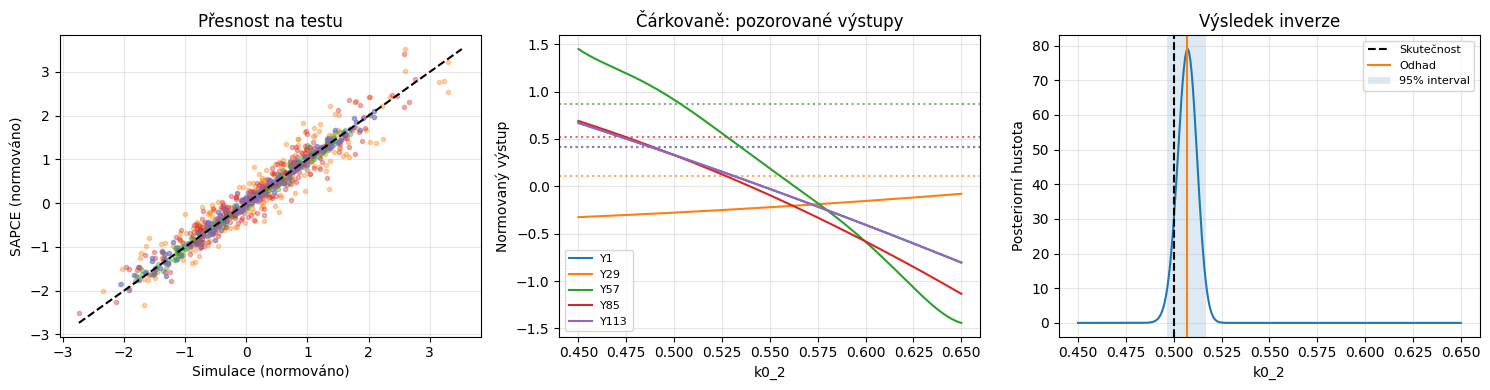

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, channel in enumerate(channels):
    axes[0].scatter(Y_test[:, k], pred[1][:, k], s=9, alpha=0.35)
    axes[1].plot(grid, pred_grid[:, k], label=f"Y{channel + 1}")
    axes[1].axhline(y_obs[k], color=f"C{k}", ls=":", alpha=0.7)
limits = [min(Y_test.min(), pred[1].min()), max(Y_test.max(), pred[1].max())]
axes[0].plot(limits, limits, "k--")
axes[0].set(xlabel="Simulace (normováno)", ylabel="SAPCE (normováno)", title="Přesnost na testu")
axes[1].set(xlabel=theta_name, ylabel="Normovaný výstup", title="Čárkovaně: pozorované výstupy")
axes[1].legend(fontsize=8)
axes[2].plot(grid, density)
axes[2].axvline(theta_true, color="black", ls="--", label="Skutečnost")
axes[2].axvline(theta_est, color="C1", label="Odhad")
axes[2].axvspan(q025, q975, alpha=0.15, label="95% interval")
axes[2].set(xlabel=theta_name, ylabel="Posteriorní hustota", title="Výsledek inverze")
axes[2].legend(fontsize=8)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
out = folder / "vysledky_inverze"
out.mkdir(exist_ok=True)
fig.savefig(out / "inverze.png", dpi=180)
validation.to_csv(out / "presnost_sapce.csv", index=False)
sobol_table.to_csv(out / "sobolovy_indexy.csv", index=False)
pd.DataFrame([{"parametr": theta_name, "theta_true": theta_true, "theta_est": theta_est,
               "abs_chyba": error, "q025": q025, "q975": q975}]).to_csv(out / "inverze.csv", index=False)
np.savez(out / "prubeh.npz", grid=grid, posterior=density, obs=obs, train=train, calib=calib, test=test)
plt.show()